In [3]:
# Import CSV data into Pandas dataframe

import pandas as pd

# 'datadirectory' = folder path string
#datadirectory = '/Users/jcoleman/Documents/--LARGE DATA--/#Febo/thy1gcamp6s data set - 1/'
datadirectory = '/Users/jcoleman/Documents/--LARGE DATA--/#Febo/thy1gcamp6s data set - 2/'
# 'datafile' = full CSV filename string
#datafile = 'mThy6s2_alldrift_D4_001Z1_ROIdata.csv'
#datafile = 'DATA_mThy6s2_alldrift_D5_001Z1hz1.csv'
datafile = 'DATA_mThy6s2_alldrift_D5_001Z1hz5.csv'


df = pd.read_csv(datadirectory + datafile)

print("datafile size (row, column) = " + str(df.shape))

datafile size (row, column) = (16200, 641)


In [4]:
# Describe data
# Get specific headers for analysis - choose from:
calcium_data_headers = ['Area',
                        'Mean', 
                        'X',
                        'Y',
                        'Circ',
                        'IntDen',
                        'RawIntDen',
                        'AR',
                        'Round',
                        'Solidity']
print(calcium_data_headers)
print("  Total number of frames/TIFs = " + str(df.shape[0]))
print("  No. of ROIs/cells = " + str(int((df.shape[1]-1)/len(calcium_data_headers))))
print("  Dealyed start - no stim/gray-only [start,stop] indices: [0,1590]")
print("  First pre-stim gray epoch [start,stop] indices: [1591,1800]")
print("  First stim epoch [start,stop] indices = [1801,1950]")
print("   -- REPEAT FOR 7 more gray-stim pairs; remainder of signal is gray only")
print("  pre-stim gray = 210 frames (7sec); stim duration = 150 frames (5sec)")

['Area', 'Mean', 'X', 'Y', 'Circ', 'IntDen', 'RawIntDen', 'AR', 'Round', 'Solidity']
  Total number of frames/TIFs = 16200
  No. of ROIs/cells = 64
  Dealyed start - no stim/gray-only [start,stop] indices: [0,1590]
  First pre-stim gray epoch [start,stop] indices: [1591,1800]
  First stim epoch [start,stop] indices = [1801,1950]
   -- REPEAT FOR 7 more gray-stim pairs; remainder of signal is gray only
  pre-stim gray = 210 frames (7sec); stim duration = 150 frames (5sec)


In [5]:
# Import as array, plot raw traces

# raw signal data for each ROI under 'RawIntDen1', etc...
# use 'RawIntDen' columns, ie the raw integrated density values/pixel brightness
#  *note IntDen columns are the same, but use the RawIntDen columns for this code per convention
# gray values between 0-64000 where 0=black, 64000=white
print(df.filter(like=calcium_data_headers[6]).columns)

Index(['RawIntDen1', 'RawIntDen2', 'RawIntDen3', 'RawIntDen4', 'RawIntDen5',
       'RawIntDen6', 'RawIntDen7', 'RawIntDen8', 'RawIntDen9', 'RawIntDen10',
       'RawIntDen11', 'RawIntDen12', 'RawIntDen13', 'RawIntDen14',
       'RawIntDen15', 'RawIntDen16', 'RawIntDen17', 'RawIntDen18',
       'RawIntDen19', 'RawIntDen20', 'RawIntDen21', 'RawIntDen22',
       'RawIntDen23', 'RawIntDen24', 'RawIntDen25', 'RawIntDen26',
       'RawIntDen27', 'RawIntDen28', 'RawIntDen29', 'RawIntDen30',
       'RawIntDen31', 'RawIntDen32', 'RawIntDen33', 'RawIntDen34',
       'RawIntDen35', 'RawIntDen36', 'RawIntDen37', 'RawIntDen38',
       'RawIntDen39', 'RawIntDen40', 'RawIntDen41', 'RawIntDen42',
       'RawIntDen43', 'RawIntDen44', 'RawIntDen45', 'RawIntDen46',
       'RawIntDen47', 'RawIntDen48', 'RawIntDen49', 'RawIntDen50',
       'RawIntDen51', 'RawIntDen52', 'RawIntDen53', 'RawIntDen54',
       'RawIntDen55', 'RawIntDen56', 'RawIntDen57', 'RawIntDen58',
       'RawIntDen59', 'RawIntDen60', 'Raw

In [6]:
df2 = df.filter(regex=calcium_data_headers[6])
print(df2)

       RawIntDen1  RawIntDen2  RawIntDen3  RawIntDen4  RawIntDen5  RawIntDen6  \
0           11483       10211       13445       19719       17738       29694   
1            7407       17082       16100       19171       19353       17883   
2           18050       11342       16151       20902       17074       36694   
3            9516       11443       12748       18634       14712       26030   
4            8521       14720       17638       12686       15069       33994   
...           ...         ...         ...         ...         ...         ...   
16195       12369       12502       12513       17112       19288       25000   
16196        9374       19491        9153       13247       14606       30544   
16197        9230       16046       17882       12010       17146       28192   
16198       15244       13014       11814       14544       14747       25480   
16199        9668       13208       11324       11263       17210       31476   

       RawIntDen7  RawIntDe

In [19]:
import numpy as np

df2_array = df2.to_numpy()
#df[["column1","column2"]].to_numpy()

#df2_array_reshape = df2_array.reshape(32,16200)

#df2_array_reshape.shape

In [20]:
(df2_array[:,31])

array([ 8360,  9236,  6693, ..., 11364,  7553,  8582])

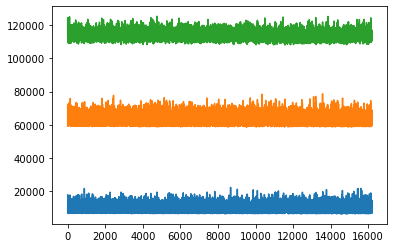

In [21]:
# plot individual raw data roi-traces

from matplotlib import pyplot as plt

#each row in df2_array is signal from a single region of interest (ROI = single GCaMP6s+ cell)
#plot the first 3 ROI traces (with incremental increase Y for spacing/plotting)
plt.plot(df2_array[:,0])
plt.plot(df2_array[:,1]+50000)
plt.plot(df2_array[:,2]+100000)

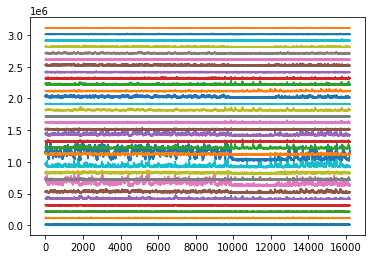

In [22]:
# plot all raw data roi-traces

for roi in range(len(df2_array[0])):
    plt.plot(df2_array[:,roi]+roi*100000)
    

In [23]:
# Corresponding XY coordinates for RawIntDen from ROIs
# See ROI maps from Jason (EPS, PNG, TIF)
print(df.filter(like=calcium_data_headers[2]).columns)
print(df.filter(like=calcium_data_headers[3]).columns)

df_x = df.filter(regex=calcium_data_headers[2])
#print(df_x)
df_y = df.filter(regex=calcium_data_headers[3])
#print(df_y)




Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23', 'X24', 'X25', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31',
       'X32'],
      dtype='object')
Index(['Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6', 'Y7', 'Y8', 'Y9', 'Y10', 'Y11',
       'Y12', 'Y13', 'Y14', 'Y15', 'Y16', 'Y17', 'Y18', 'Y19', 'Y20', 'Y21',
       'Y22', 'Y23', 'Y24', 'Y25', 'Y26', 'Y27', 'Y28', 'Y29', 'Y30', 'Y31',
       'Y32'],
      dtype='object')


In [28]:
# EXAMPLE - Annotate timestamps for the first ...gray-stim... sequence
# In the last plot, red indicates initial gray screen,
#   cyan underscores the first "pre-stim gray screen" x-range
#   green underscores the first "stim screen" x-range
#   blue underscores the second "pre-stim gray screen" x-range
#
# Timestamps (approximate - within +/-5frames?)
frames_Hz = 30

# Plot vertical lines
#   (60s delay before forst stim onset | 5sec stim/visual | 7sec gray/rest | repeat for 7 more stims/grays) 
#   (Total 8 drifting grating stims = 0,45,90,135,180,225,270,315 degrees (off horizon))
# 1) start_delay [0]
# 2) stop_delay (60s delay before forst stim onset) [60*frames_Hz]

# Select the ROI (i.e. column)
roi=8
# Define indices for the first 'delayed' gray screen (60s, 1800frames)
delay_start = 0
delay_stop = 60*frames_Hz #-1 maybe to compensate for [0:60] in Python vs (1:60) in Matlab?
delay_start_stop = df2_array[delay_start:delay_stop,roi] 
# Define indices for the first 'gray' pre-stimulus stretch
gray_duration_frames = 7*frames_Hz
# Subtract the first gray pre-stim, 'gray0' from the initial 1800 frames
# This is the actual 'delayed' part
start_gray0 = delay_stop-(7*frames_Hz)
stop_gray0 = start_gray0 + gray_duration_frames
gray0_start_stop = df2_array[start_gray0:stop_gray0,roi]

stim_duration_frames = 5*frames_Hz
start_stim0 = delay_stop + 1
stop_stim0 = delay_stop + stim_duration_frames
stim0_start_stop = df2_array[start_stim0:stop_stim0,roi]
# 5) start_gray1 [stop_stim1 + 1]
# 6) stop_gray1 [stop_stim1 + 7*frames_Hz]
start_gray1 = stop_stim0 + 1
stop_gray1 = stop_stim0 + gray_duration_frames
gray1_start_stop = df2_array[start_gray1:stop_gray1,roi]
# 7) start_stim2 [stop_gray1 + 1]
# 8) stop_stim2 [stop_gray1 + 5*frames_Hz]
# 9) start_gray2 [stop_stim2 + 1]
#10) stop_gray2 [stop_stim2 = 7*frames_Hz]
#11) start_stim3 [stop_gray1 + 1] ...
# ... repeat up until stim8 / gray8
# print(delay_start_stop.shape)
# print(start_stim1)
# print(stop_stim1)
# print(start_gray1)
# print(stop_gray1)

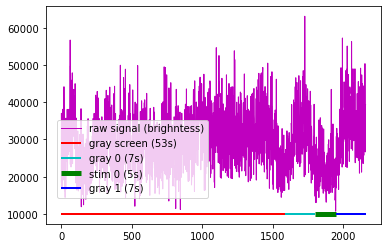

In [29]:
# Plotting exercises to show indices for events (e.g., gray-stim screen switching)

# plt.plot(delay_start_stop)
# plt.plot(df2_array[start_stim1:stop_gray1,roi])
# plt.plot(stim_start_stop)


plt.plot(df2_array[0:stop_gray1,roi], linewidth=1, color='m', label='raw signal (brighntess)')
#plt.axhline(y=0.5, color='r', linestyle='-')
plt.hlines(y=10000, xmin=0, xmax=60*frames_Hz, linewidth=2, color='r', label='gray screen (53s)')
gray0 = start_stim0-(7*frames_Hz)
plt.hlines(y=10000, xmin=gray0, xmax=start_stim0-1, linewidth=2, color='c', label='gray 0 (7s)')
plt.hlines(y=10000, xmin=start_stim0, xmax=stop_stim0, linewidth=5, color='g', label='stim 0 (5s)')
plt.hlines(y=10000, xmin=start_gray1, xmax=stop_gray1, linewidth=2, color='b', label='gray 1 (7s)')
# then repeat stim(5s)-gray(7s) for 8 total 'pairs/periods'
# the idea is to use the pre-stim gray (or average across trials) for normalizing stim signal

#plt.legend({ 'raw signal (brighntess)', 'gray screen (53s)', 'gray 0 (7s)', 'stim 0 (5s)', 'gray 1 (7s)' })
#plt.legend()
plt.legend(loc=5, bbox_to_anchor=(0.5,0.3))

In [30]:
#Visual stimuli info (drifting sinusoidal gratings, 0.05cpd, 10Hz drift rate interleaved with gray screen)
"""
Orientations of drifting sinusoidal gratings (x8, 50% contrast)
stims_drifting = {'stim1':0,'stim2':45,'stim3':90,'stim4':135,'stim5':=180,'stim6':225,'stim7':270,'stim8':315}

stim duration = 5s
gray (inter-stim) duration = 7s
start delay = 60sec
16200 frames (9m7s on bscope streaming)
drift rate = 3Hz? (true = 1.5?)

mon width  = 52 cm
distance = 14 cm
hoiz = 1920; vert = 1080 pix

5s, 7s gray
0,45,90,135,180,225,270,315
5 sessions
60s delay
= (16200 frames = 9m7s)
"""


"\nOrientations of drifting sinusoidal gratings (x8, 50% contrast)\nstims_drifting = {'stim1':0,'stim2':45,'stim3':90,'stim4':135,'stim5':=180,'stim6':225,'stim7':270,'stim8':315}\n\nstim duration = 5s\ngray (inter-stim) duration = 7s\nstart delay = 60sec\n16200 frames (9m7s on bscope streaming)\ndrift rate = 3Hz? (true = 1.5?)\n\nmon width  = 52 cm\ndistance = 14 cm\nhoiz = 1920; vert = 1080 pix\n\n5s, 7s gray\n0,45,90,135,180,225,270,315\n5 sessions\n60s delay\n= (16200 frames = 9m7s)\n"

In [ ]:
# IN PROGRESS - CREATE dicts() w/ indices for gray, stims etc


# could do:
# stims_drifting = {'stim0':[<stim orientation>,
#                            (pre-gray (start,stop) indices - tuple),
#                            (stim (start,stop) indices - tuple)]}
# stims_drifting = {'stim0':[0,(pre,gray),(210,360)]}
stims_drifting = {'stim0':[0,(210,360)],'stim1':45,'stim2':90,'stim3':135,'stim4':180,'stim5':225,'stim6':270,'stim7':315}
# stimulus orientation (degrees)
print('stimulus orientation (degrees) => ' + str(stims_drifting['stim0'][0]))
# tuple with indices for df2 (start, stop)
print('tuple with start-stop indices for df2 (start, stop) => ' + str(stims_drifting['stim0'][1]))

In [ ]:
stims_startStop_indices = {'stim0':(210,360),'stim1':45,'stim2':90,'stim3':135,'stim4':180,'stim5':225,'stim6':270,'stim7':315}

In [ ]:
grays_startStop_indices = {'stim0':(0,209),'stim1':45,'stim2':90,'stim3':135,'stim4':180,'stim5':225,'stim6':270,'stim7':315}

In [ ]:
stims_startStop_indices['stim0']

In [ ]:
# start-stop indices as tuples
type(stims_startStop_indices['stim0'])
#type(grays_startStop_indices['stim0'])